In [1]:
# Task 3: Autoregressive Transformer with miditok REMI
import sys
sys.path.append("../src")

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
import matplotlib.pyplot as plt
import math
import miditok

from models.transformer import MusicTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Load tokenized data
train_tokens = np.load("../data/tokens/tokens_train.npy")
val_tokens   = np.load("../data/tokens/tokens_val.npy")
test_tokens  = np.load("../data/tokens/tokens_test.npy")

print("Train chunks:", train_tokens.shape)
print("Val chunks:  ", val_tokens.shape)
print("Test chunks: ", test_tokens.shape)

VOCAB_SIZE = 284  # miditok REMI vocabulary size
PAD_ID = 0


Train chunks: (39757, 512)
Val chunks:   (4483, 512)
Test chunks:  (5157, 512)


In [3]:
# Dataset
class TokenDataset(Dataset):
    def __init__(self, tokens):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
    def __len__(self):
        return len(self.tokens)
    def __getitem__(self, idx):
        seq = self.tokens[idx]
        x = seq[:-1]   # input: all but last token
        y = seq[1:]    # target: all but first token (shifted by 1)
        return x, y

train_dataset = TokenDataset(train_tokens)
val_dataset   = TokenDataset(val_tokens)
test_dataset  = TokenDataset(test_tokens)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)
print(f"Batches - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches - train: 1243, val: 141, test: 162


In [4]:
# Initialize model
model = MusicTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    nhead=4,
    num_layers=4,
    dim_feedforward=512,
    max_seq_len=512,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

# Loss: cross-entropy ignoring padding
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# Adam with lr=1e-3 (guideline Section D recommendation)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# LR scheduler: reduce on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

def calc_perplexity(loss):
    return math.exp(min(loss, 20))  # cap to prevent overflow


Model parameters: 2,385,180


In [5]:
# Training loop
num_epochs = 20
train_losses = []
val_losses = []
train_perplexities = []
val_perplexities = []

output_dir = Path("../outputs/generated_midis/task3_transformer")
output_dir.mkdir(parents=True, exist_ok=True)
Path("../outputs/checkpoints").mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        # logits: (batch, seq_len, vocab) -> (batch*seq_len, vocab)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)
    train_perplexities.append(calc_perplexity(avg_train))

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    val_perplexities.append(calc_perplexity(avg_val))

    scheduler.step(avg_val)

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "../outputs/checkpoints/transformer_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Train PPL: {train_perplexities[-1]:.2f} | Val PPL: {val_perplexities[-1]:.2f}")


Epoch [1/20] | Train Loss: 2.5810 | Val Loss: 2.3883 | Train PPL: 13.21 | Val PPL: 10.90


Epoch [2/20] | Train Loss: 2.2829 | Val Loss: 2.2136 | Train PPL: 9.81 | Val PPL: 9.15


Epoch [3/20] | Train Loss: 2.1715 | Val Loss: 2.1328 | Train PPL: 8.77 | Val PPL: 8.44


Epoch [4/20] | Train Loss: 2.1149 | Val Loss: 2.0980 | Train PPL: 8.29 | Val PPL: 8.15


Epoch [5/20] | Train Loss: 2.0803 | Val Loss: 2.0700 | Train PPL: 8.01 | Val PPL: 7.93


...

Epoch [16/20] | Train Loss: 1.9595 | Val Loss: 1.9819 | Train PPL: 7.10 | Val PPL: 7.26


Epoch [17/20] | Train Loss: 1.9555 | Val Loss: 1.9799 | Train PPL: 7.07 | Val PPL: 7.24


Epoch [18/20] | Train Loss: 1.9518 | Val Loss: 1.9780 | Train PPL: 7.04 | Val PPL: 7.23


Epoch [19/20] | Train Loss: 1.9483 | Val Loss: 1.9721 | Train PPL: 7.02 | Val PPL: 7.19


Epoch [20/20] | Train Loss: 1.9452 | Val Loss: 1.9735 | Train PPL: 6.99 | Val PPL: 7.20


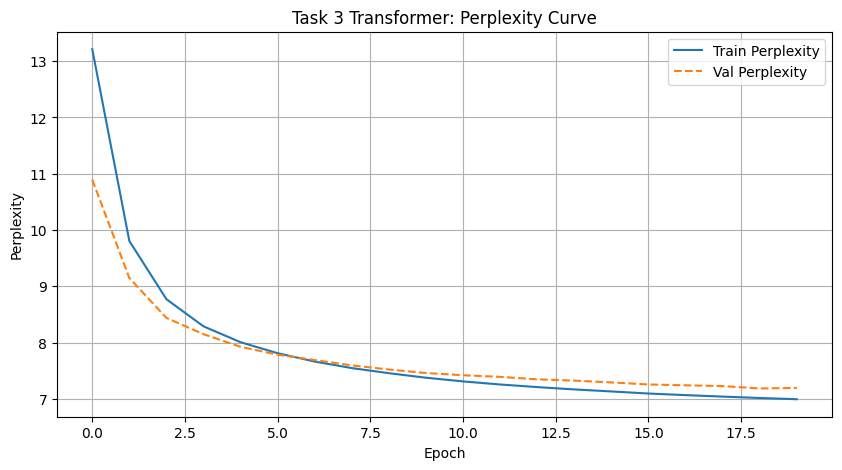

Best Val Perplexity: 7.19


In [6]:
# Plot perplexity curve (guideline Step 11: plot perplexity for Task 3)
plt.figure(figsize=(10, 5))
plt.plot(train_perplexities, label="Train Perplexity", linestyle="-")
plt.plot(val_perplexities, label="Val Perplexity", linestyle="--")
plt.legend()
plt.title("Task 3 Transformer: Perplexity Curve")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.grid(True)
plt.show()
print(f"Best Val Perplexity: {min(val_perplexities):.2f}")


In [7]:
# Evaluate on test set
model.load_state_dict(torch.load("../outputs/checkpoints/transformer_best.pth"))
model.eval()

test_loss = 0.0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        test_loss += loss.item()

avg_test = test_loss / len(test_loader)
test_ppl = calc_perplexity(avg_test)
print(f"Test Loss: {avg_test:.4f} | Test Perplexity: {test_ppl:.2f}")


Test Loss: 1.8909 | Test Perplexity: 6.63


In [8]:
# Generation: temperature + top-k sampling (guideline fix for repetition loops)
def top_k_sample(logits, temperature=1.0, top_k=40):
    logits = logits / temperature
    if top_k > 0:
        values, _ = torch.topk(logits, top_k)
        min_val = values[:, -1].unsqueeze(-1)
        logits = logits.masked_fill(logits < min_val, float("-inf"))
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)

def generate(model, tokenizer, seed_token_id, max_new_tokens=1000,
             temperature=1.0, top_k=40):
    model.eval()
    tokens = [seed_token_id]
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Use last 511 tokens to stay within max_seq_len
            context = torch.tensor([tokens[-511:]], dtype=torch.long, device=device)
            logits = model(context)
            next_logits = logits[0, -1, :]  # last time step
            next_token = top_k_sample(next_logits.unsqueeze(0), temperature, top_k)
            next_id = next_token.item()
            tokens.append(next_id)
    return tokens

# Reload tokenizer
tokenizer = miditok.REMI()

# Find a Bar token as seed (token type "Bar" has id 4 in default REMI)
BAR_TOKEN_ID = 4
print(f"Seed token ID: {BAR_TOKEN_ID}")


Seed token ID: 4


In [9]:
# Generate 10 compositions (guideline requires 10 for Task 3)
for i in range(10):
    print(f"Generating composition {i+1}/10...")
    token_ids = generate(
        model, tokenizer,
        seed_token_id=BAR_TOKEN_ID,
        max_new_tokens=1000,
        temperature=1.0,
        top_k=40
    )

    # Convert token IDs -> TokSequence -> MIDI using miditok
    from miditok import TokSequence
    tok_seq = TokSequence(ids=token_ids)
    tokenizer.complete_sequence(tok_seq)

    midi_obj = tokenizer([tok_seq])
    out_path = output_dir / f"task3_generated_{i+1}.mid"
    midi_obj.dump_midi(out_path)
    print(f"  Saved: {out_path}")

print("All 10 compositions generated!")


Generating composition 1/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_1.mid
Generating composition 2/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_2.mid
Generating composition 3/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_3.mid
Generating composition 4/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_4.mid
Generating composition 5/10...


...

  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_6.mid
Generating composition 7/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_7.mid
Generating composition 8/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_8.mid
Generating composition 9/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_9.mid
Generating composition 10/10...


  Saved: ..\outputs\generated_midis\task3_transformer\task3_generated_10.mid
All 10 compositions generated!
